In [1]:
import pandas as pd 
import numpy as  np 
import matplotlib.pyplot as   plt 
import seaborn as sns

import sys

sys.path.append('./source')
from sklearn.model_selection import train_test_split


## Importation des fonctions


In [2]:
from onlineMROTrate_eval import OnlineMROTADrate  

2026-02-11 19:17:43.811427: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-11 19:17:43.920831: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770833864.021307  262412 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770833864.050524  262412 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770833864.256165  262412 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770833864.256197  262412 computation_placer.cc:177] computation placer already registered. Please che

In [3]:

from utils import plot_auc_over_time, plot_auc_with_drift, split_data

from onlineMROTwassertein import OnlineMROTADWassertein

In [4]:
s1 = pd.read_csv("./datasets/cao2025/S1.csv")

In [5]:
data = s1.iloc[:,:-2]

drift_labels = s1.iloc[:,-1]
true_labels = s1.iloc[:,-2]

In [6]:
X_train, X_test, y_drift_train, y_drift_test, y_true_train, y_true_test = split_data(data, drift_labels, true_labels, n_train_samples=1000)

In [7]:
od = OnlineMROTADrate(
    mrot_params={},
    window_size=200,
    n_history=5,            
    m_barycenter=3,
    tau_anomaly=0.6,
    K_retrain=5,
    data_online=pd.DataFrame(X_test, columns=data.columns),
    y_true_online=y_true_test,
    data_offline=pd.DataFrame(X_train, columns=data.columns),
    y_true_offline=y_true_train,
)       

Anomaly scores for initial data computed. AUC Score: 0.9884654352739459


In [8]:
result = od.online_tumbling_window()

  DRIFT détecté ! Taux d'anomalies: 0.855 (seuil: 0.6)
 Model retrained successfully!
  DRIFT détecté ! Taux d'anomalies: 1.000 (seuil: 0.6)
 Model retrained successfully!
  DRIFT détecté ! Taux d'anomalies: 0.640 (seuil: 0.6)
 Model retrained successfully!


AUC Lists: 0.8052255695138975


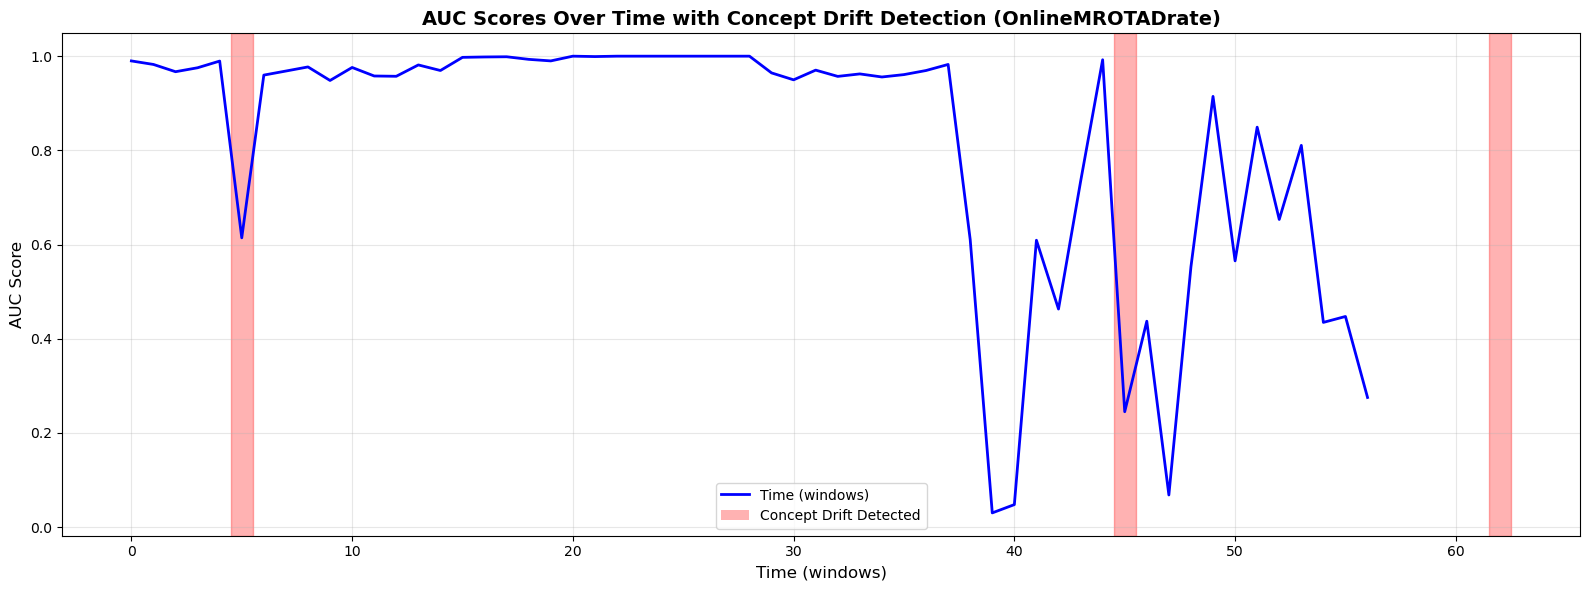

(<Figure size 1600x600 with 1 Axes>,
 <Axes: title={'center': 'AUC Scores Over Time with Concept Drift Detection (OnlineMROTADrate)'}, xlabel='Time (windows)', ylabel='AUC Score'>)

In [9]:
auc_lists = result[3]
drift_indicators = result[1] 
print("AUC Lists:", result[2])


plot_auc_with_drift(auc_lists, drift_indicators, xlabel="Time (windows)", ylabel="AUC Score", title="AUC Scores Over Time with Concept Drift Detection (OnlineMROTADrate)")

In [10]:
result2 = od.online_sliding_window()

In [11]:
len(auc_lists)

57

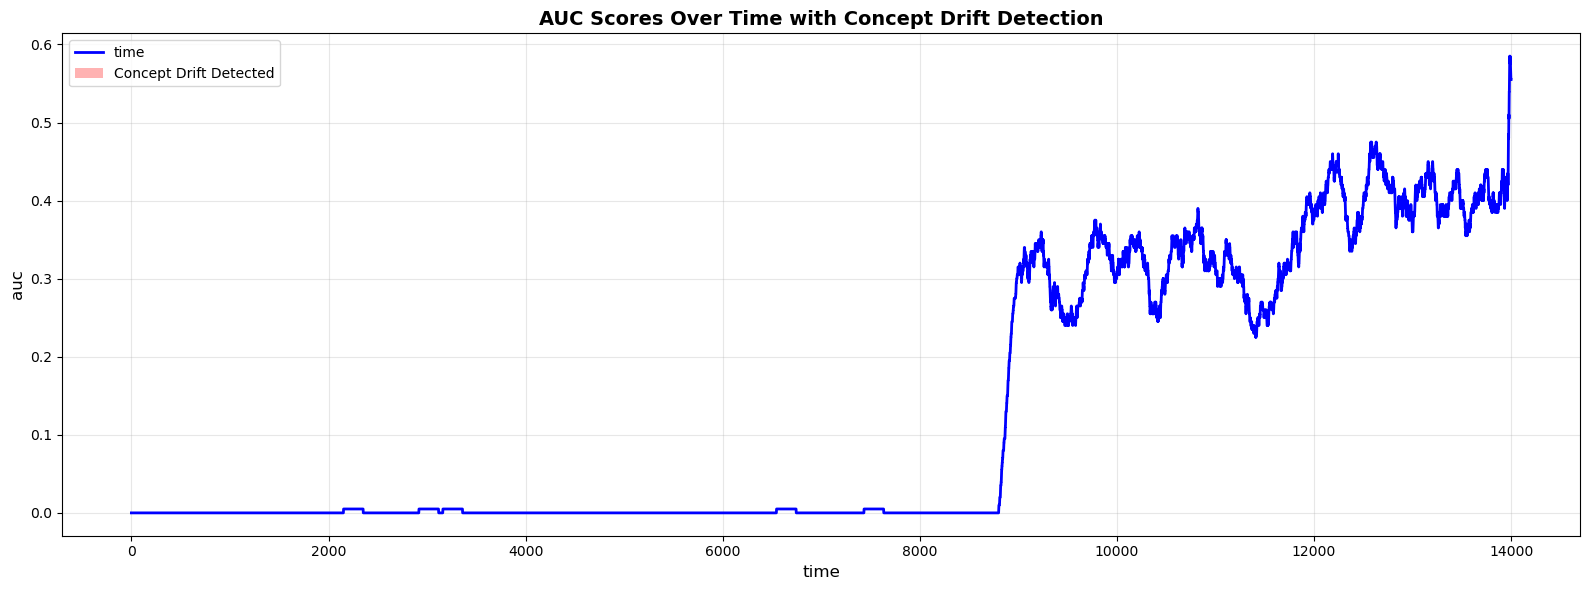

(<Figure size 1600x600 with 1 Axes>,
 <Axes: title={'center': 'AUC Scores Over Time with Concept Drift Detection'}, xlabel='time', ylabel='auc'>)

In [12]:
auc_lists = result2[0]
drift_indicators = result2[1] 


plot_auc_with_drift(auc_lists, drift_indicators)

In [13]:
result_set= []

In [14]:
for threshold in [0.2, 0.25, 0.3, 0.4]:
    od.auc_drop_threshold = threshold
    result_set.append(od.online_tumbling_window())
    drift_count = sum(result_set[0][1])
    print(f"Threshold={threshold:.2f} → {drift_count} détections")

Threshold=0.20 → 0 détections
Threshold=0.25 → 0 détections
Threshold=0.30 → 0 détections
Threshold=0.40 → 0 détections


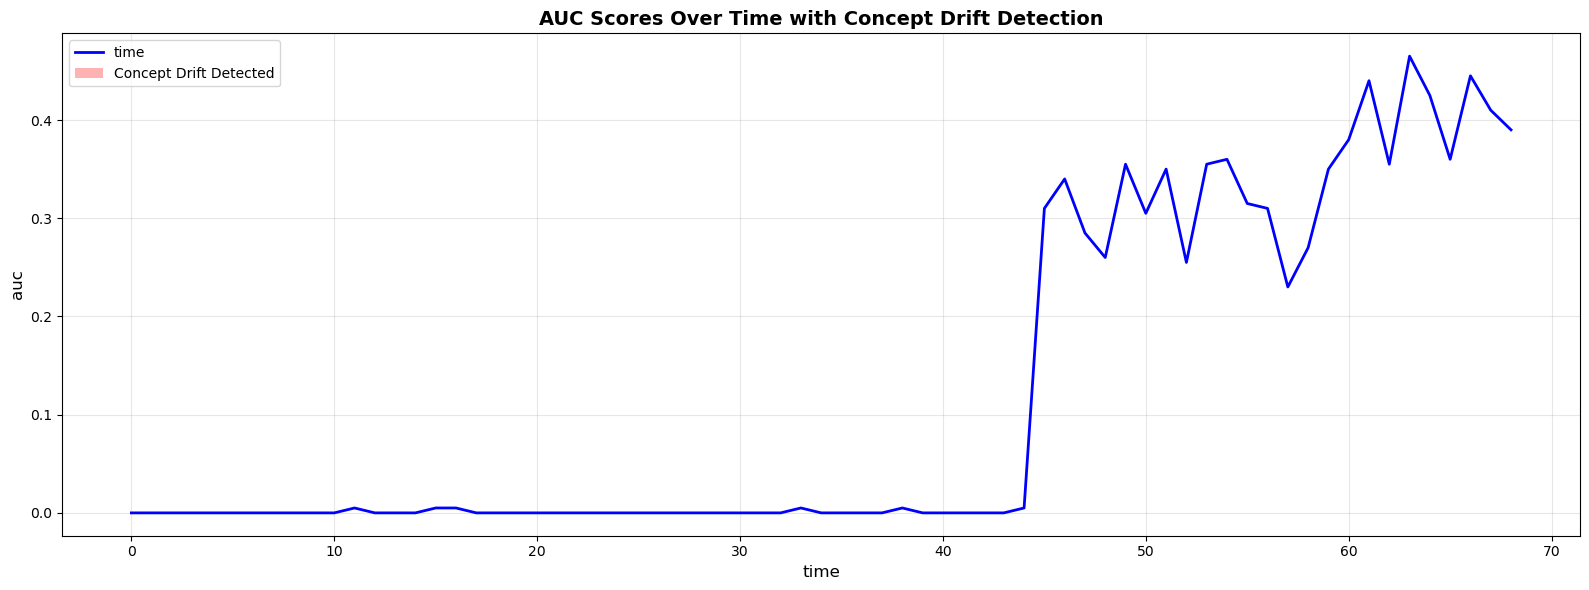

(<Figure size 1600x600 with 1 Axes>,
 <Axes: title={'center': 'AUC Scores Over Time with Concept Drift Detection'}, xlabel='time', ylabel='auc'>)

In [15]:
auc_lists = result_set[1][0] 
drift_indicators = result_set[1][1]


plot_auc_with_drift(auc_lists, drift_indicators)

# 2 - Wassertein

In [16]:
ow =  OnlineMROTADWassertein(
    mrot_params={},
    window_size=200,
    n_history=5,            
    m_barycenter=10,
    theta_validation=0.75,
    tau_anomaly=0.75,
    K_retrain=5,
    data_online=pd.DataFrame(X_test, columns=data.columns),
    y_true_online=y_true_test,
    data_offline=pd.DataFrame(X_train, columns=data.columns),
    y_true_offline=y_true_train,
    drift_threshold=0.5
)       

Anomaly scores for initial data computed. AUC Score: 0.9884654352739459


In [17]:
score_list, drift_detected_list, wasserstein_score = ow.online_wasserstein_structured()

Window 1: AUC=0.9899, Wasserstein=0.0000
Window 2: AUC=0.9824, Wasserstein=0.0000
Window 3: AUC=0.9670, Wasserstein=0.0000
Window 4: AUC=0.9754, Wasserstein=0.0000
Window 5: AUC=0.9896, Wasserstein=0.0000
 WASSERSTEIN DRIFT! Distance: 3.2117 > Threshold: 0.5000
 PERFORMANCE DRIFT! AUC below threshold: 0.6142
Window 6: AUC=0.6142, Wasserstein=3.2117
 Model retrained successfully!
 Drift detected: Model updated, historical windows NOT updated.
 WASSERSTEIN DRIFT! Distance: 3.6587 > Threshold: 0.5000
Window 7: AUC=0.9598, Wasserstein=3.6587
 Model retrained successfully!
 Drift detected: Model updated, historical windows NOT updated.
 WASSERSTEIN DRIFT! Distance: 3.1556 > Threshold: 0.5000
Window 8: AUC=0.9760, Wasserstein=3.1556
 Model retrained successfully!
 Drift detected: Model updated, historical windows NOT updated.
 WASSERSTEIN DRIFT! Distance: 3.4012 > Threshold: 0.5000
Window: Wasserstein=3.4012 (AUC not computable)
 Model retrained successfully!
 Drift detected: Model updated, 

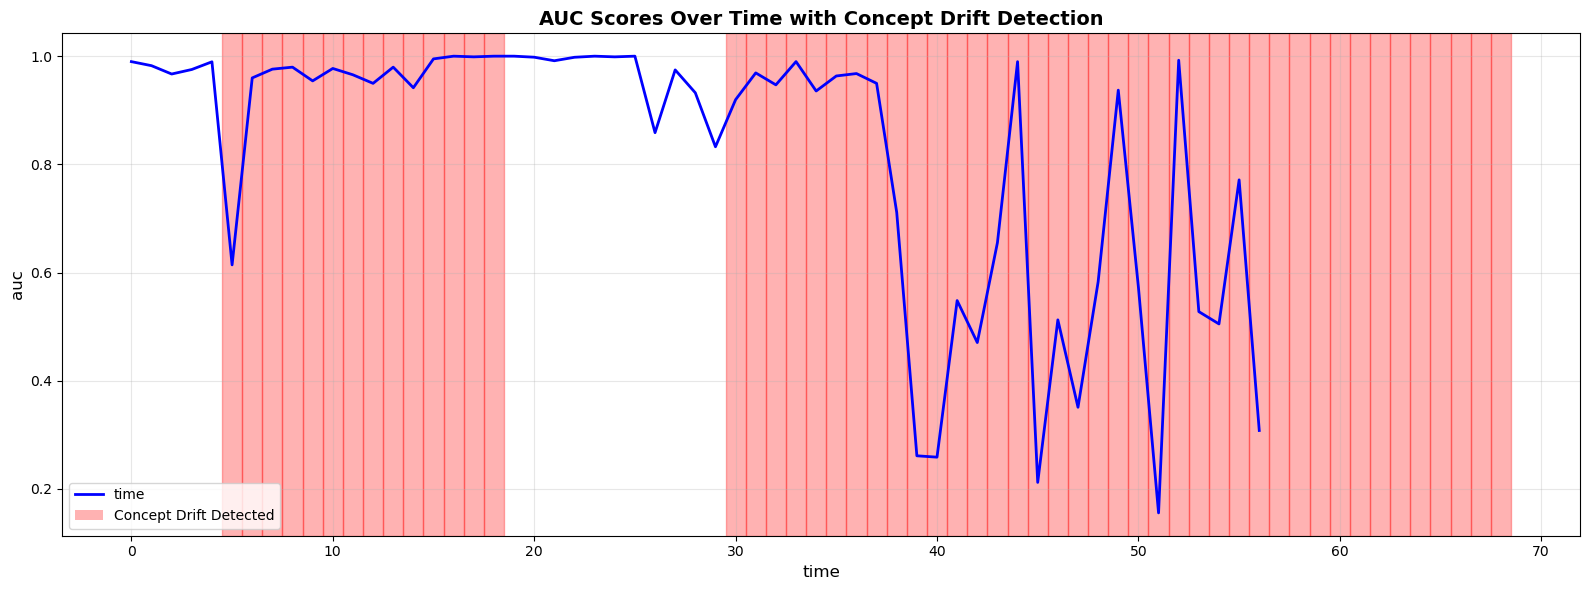

(<Figure size 1600x600 with 1 Axes>,
 <Axes: title={'center': 'AUC Scores Over Time with Concept Drift Detection'}, xlabel='time', ylabel='auc'>)

In [18]:
plot_auc_with_drift(score_list, drift_detected_list)

Text(0.5, 0, 'Window Index')

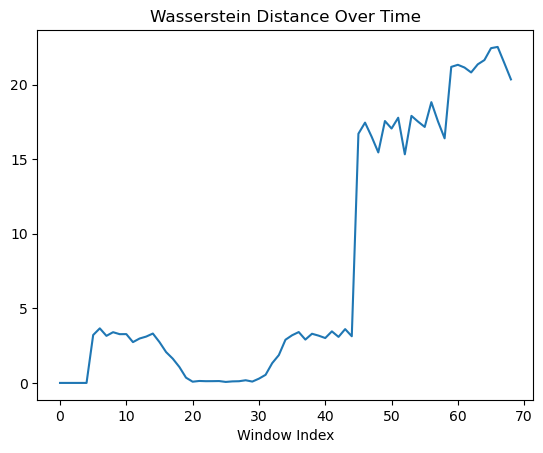

In [19]:
plt.plot(wasserstein_score)
plt.title("Wasserstein Distance Over Time")
plt.xlabel("Window Index")

In [20]:
test =  ow.online_domain_adaptation()

Window 1: AUC=0.9621
 PERFORMANCE DRIFT! AUC below threshold: 0.0075
Window 2: AUC=0.0075
 Drift detected: Model updated.
le cout de transport est   0.11613360657091656
 Model retrained successfully!
Window 3: AUC=0.9746
Window 4: AUC=0.9436
Window 5: AUC=0.9609
 PERFORMANCE DRIFT! AUC below threshold: 0.6768
Window 6: AUC=0.6768
 Drift detected: Model updated.
le cout de transport est   3.2288448791908917
 Model retrained successfully!
Window 7: AUC=0.9598
Window 8: AUC=0.9684
Window 9: AUC=0.9772
Window 10: AUC=0.9484
Window 11: AUC=0.9760
Window 12: AUC=0.9579
Window 13: AUC=0.9573
Window 14: AUC=0.9814
Window 15: AUC=0.9695
Window 16: AUC=0.9975
Window 17: AUC=0.9983
Window 18: AUC=0.9987
Window 19: AUC=0.9932
Window 20: AUC=0.9899
Window 21: AUC=1.0000
Window 22: AUC=0.9992
Window 23: AUC=1.0000
Window 24: AUC=1.0000
Window 25: AUC=1.0000
Window 26: AUC=1.0000
Window 27: AUC=1.0000
Window 28: AUC=1.0000
Window 29: AUC=1.0000
Window 30: AUC=0.9645
Window 31: AUC=0.9497
Window 32: A

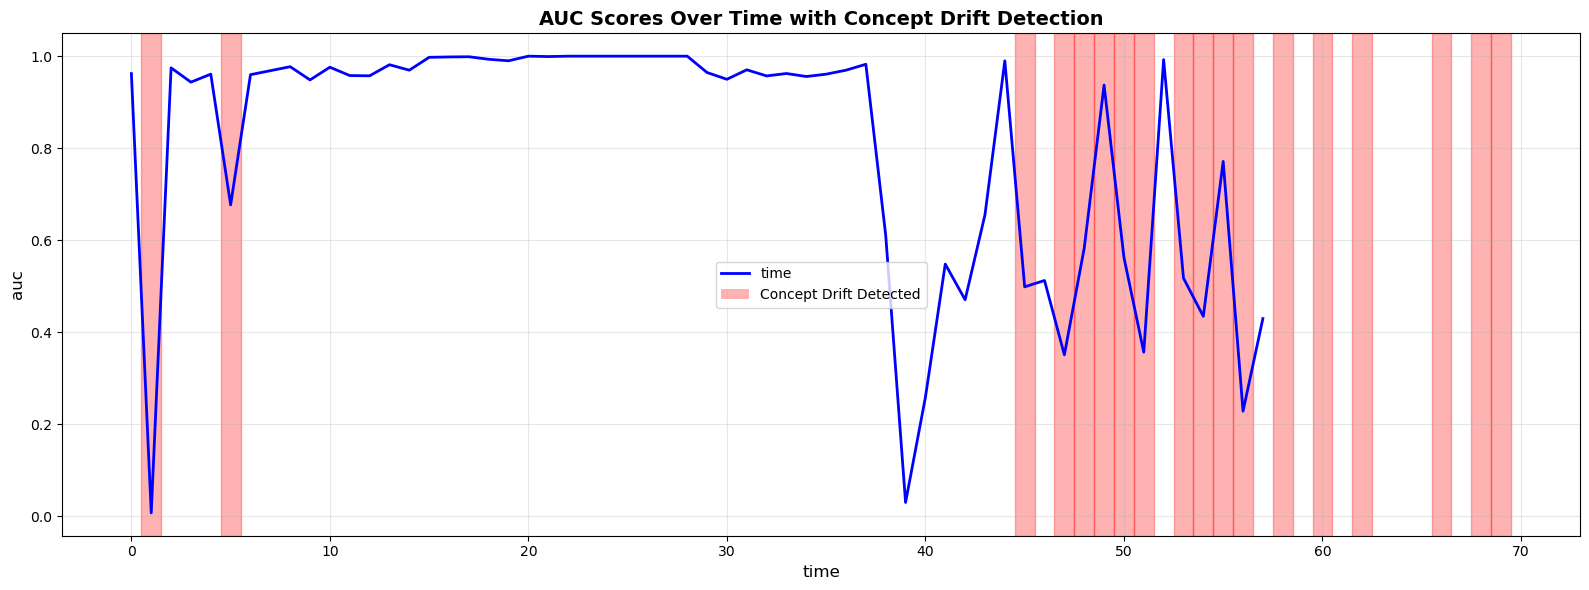

(<Figure size 1600x600 with 1 Axes>,
 <Axes: title={'center': 'AUC Scores Over Time with Concept Drift Detection'}, xlabel='time', ylabel='auc'>)

In [21]:
auc_lists = test[0]
drift_indicators = test[1] 


plot_auc_with_drift(auc_lists, drift_indicators)

In [22]:
len(drift_indicators)

70

In [23]:
from onlineMROTrate_eval import OnlineMROTADrate

In [24]:
od  = OnlineMROTADrate(
    mrot_params={},
    window_size=200,
    n_history=5,            
    m_barycenter=3,
    tau_anomaly=0.6,
    K_retrain=5,
    data_online=pd.DataFrame(X_test, columns=data.columns),
    y_true_online=y_true_test,
    data_offline=pd.DataFrame(X_train, columns=data.columns),
    y_true_offline=y_true_train,
)       

Anomaly scores for initial data computed. AUC Score: 0.9884654352739459


In [25]:
results = []

In [26]:
i = 0
for stride_value in [1, 10, 50, 100, 200]:
    results.append( od.online_sliding_window(stride=stride_value))
    print(f"Stride={stride_value}: {len(results[0])} fenêtres, "
          f"{sum(results[i][1])} drifts détectés")
    i += 1

  DRIFT détecté ! Taux d'anomalies: 0.605 (seuil: 0.6)
 Model retrained successfully!
  DRIFT détecté ! Taux d'anomalies: 0.605 (seuil: 0.6)
 Model retrained successfully!
  DRIFT détecté ! Taux d'anomalies: 0.605 (seuil: 0.6)
 Model retrained successfully!
  DRIFT détecté ! Taux d'anomalies: 0.605 (seuil: 0.6)
 Model retrained successfully!
  DRIFT détecté ! Taux d'anomalies: 0.605 (seuil: 0.6)
 Model retrained successfully!
Stride=1: 4 fenêtres, 5 drifts détectés
  DRIFT détecté ! Taux d'anomalies: 1.000 (seuil: 0.6)
 Model retrained successfully!
  DRIFT détecté ! Taux d'anomalies: 0.610 (seuil: 0.6)
 Model retrained successfully!
  DRIFT détecté ! Taux d'anomalies: 0.605 (seuil: 0.6)
 Model retrained successfully!
  DRIFT détecté ! Taux d'anomalies: 0.605 (seuil: 0.6)
 Model retrained successfully!
  DRIFT détecté ! Taux d'anomalies: 0.615 (seuil: 0.6)
 Model retrained successfully!
Stride=10: 4 fenêtres, 5 drifts détectés
Stride=50: 4 fenêtres, 0 drifts détectés
Stride=100: 4 fenê

AUC Golbal results  0.7996262118111205:


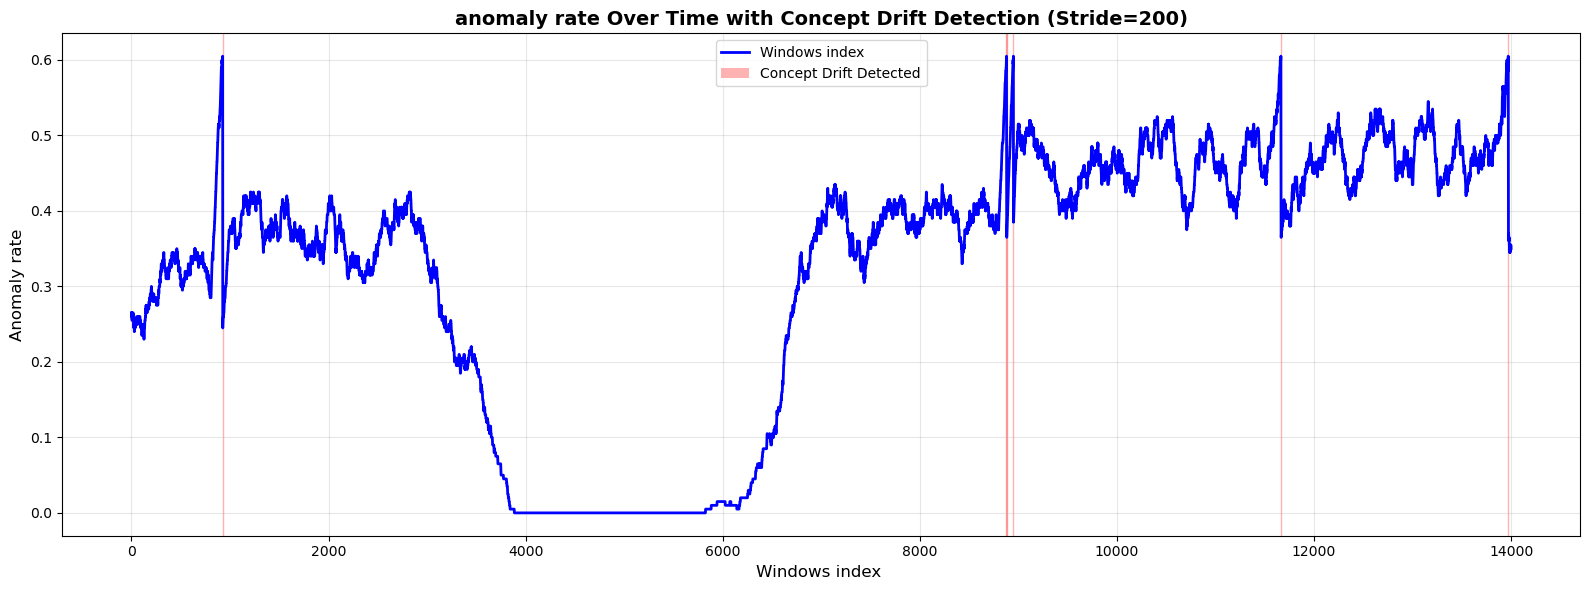

(<Figure size 1600x600 with 1 Axes>,
 <Axes: title={'center': 'anomaly rate Over Time with Concept Drift Detection (Stride=200)'}, xlabel='Windows index ', ylabel='Anomaly rate'>)

In [27]:
auc_lists = results[0][0]
drift_indicators = results[0][1]
print(f"AUC Golbal results  {results[0][2]}:")

plot_auc_with_drift(auc_lists, drift_indicators, xlabel="Windows index ", ylabel="Anomaly rate", title=f"anomaly rate Over Time with Concept Drift Detection (Stride={stride_value})")

AUC Golbal results  0.7996262118111205:


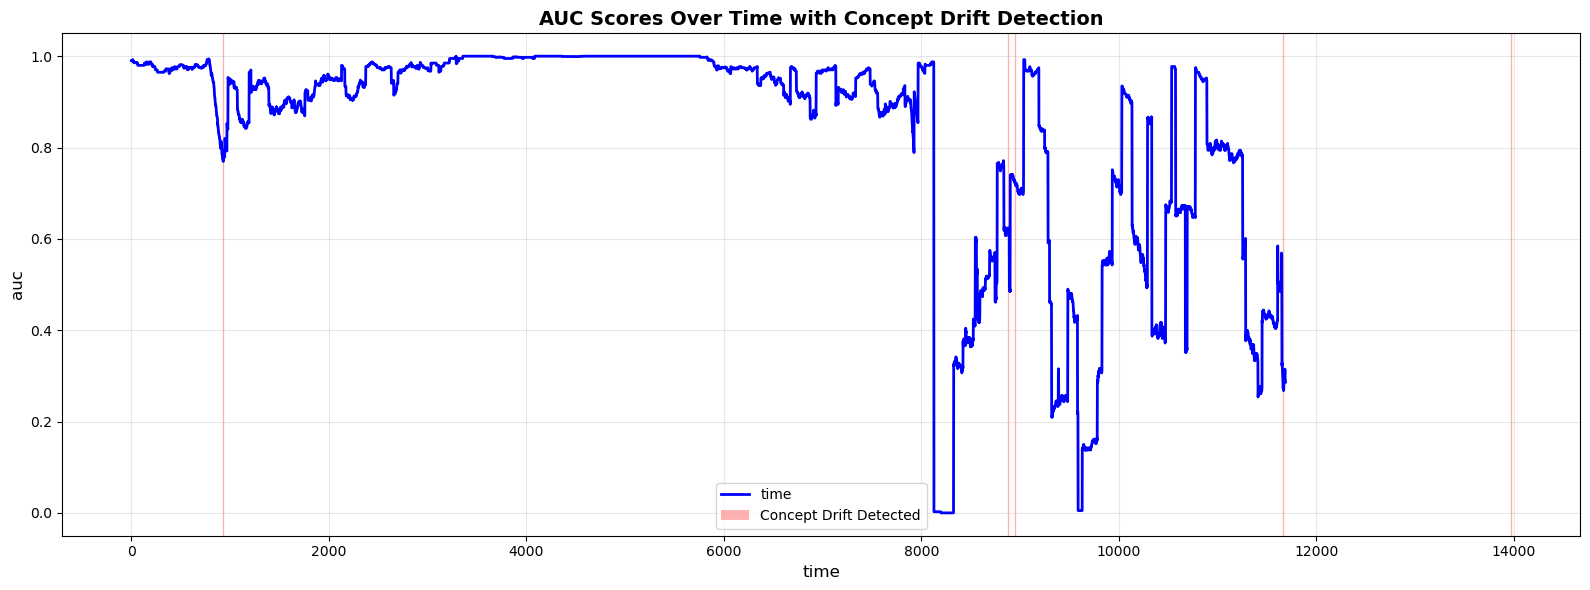

(<Figure size 1600x600 with 1 Axes>,
 <Axes: title={'center': 'AUC Scores Over Time with Concept Drift Detection'}, xlabel='time', ylabel='auc'>)

In [28]:
auc_lists = results[0][3]
drift_indicators = results[0][1]
print(f"AUC Golbal results  {results[0][2]}:")

plot_auc_with_drift(auc_lists, drift_indicators)

AUC Golbal results  0.7996262118111205:
Stride=1: 11688 fenêtres, 5 drifts détectés


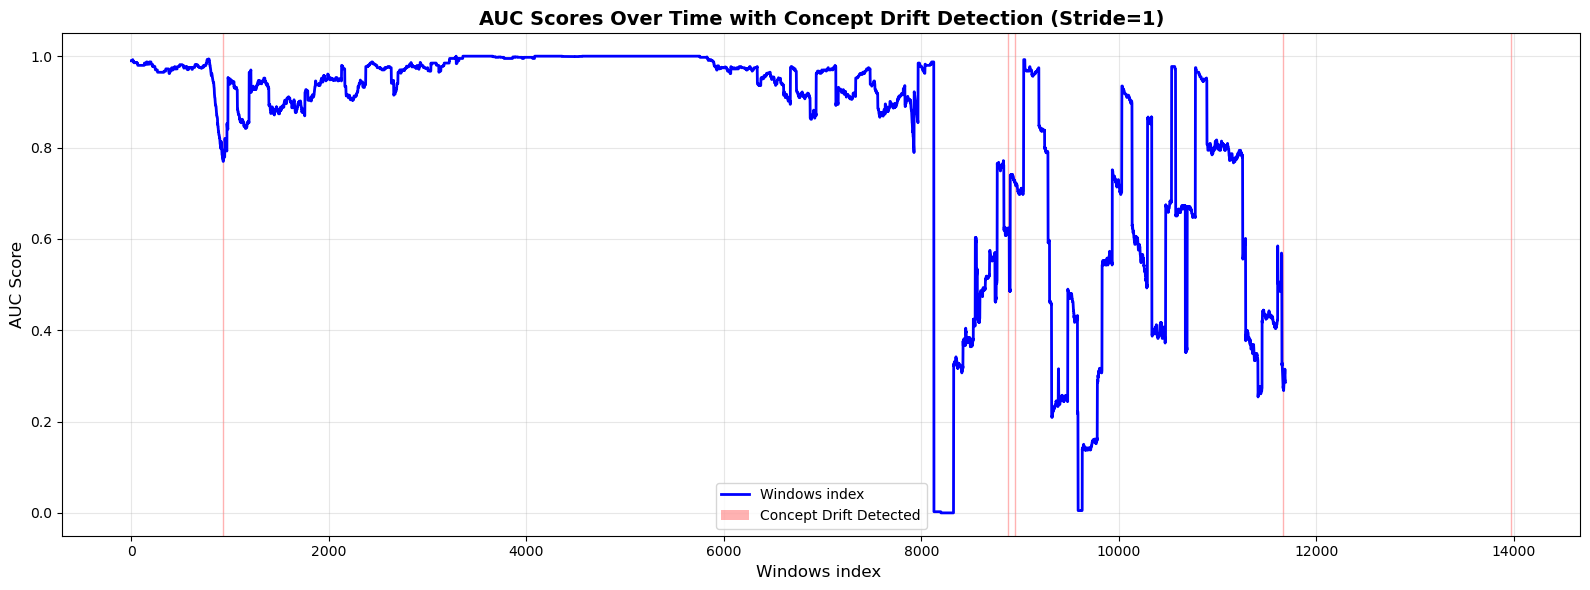

AUC Golbal results  0.8003626181851293:
Stride=10: 1171 fenêtres, 5 drifts détectés


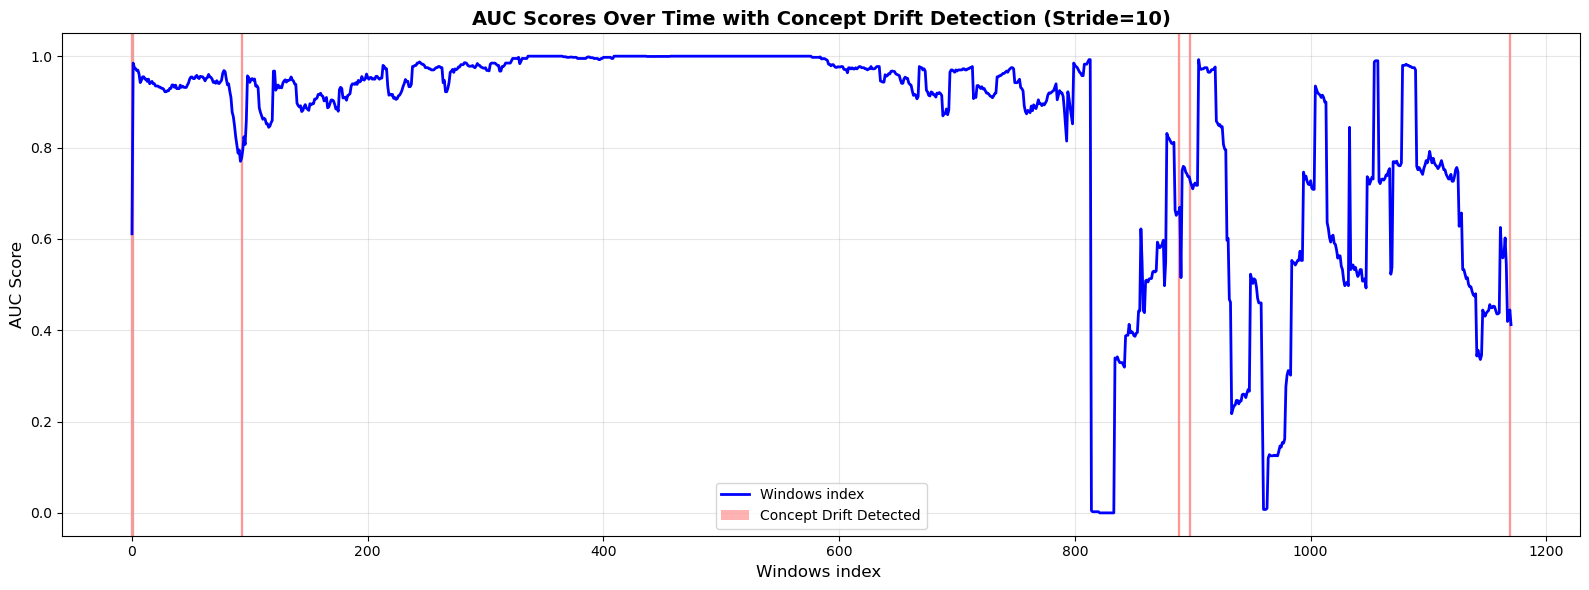

AUC Golbal results  0.6734304787982577:
Stride=50: 235 fenêtres, 0 drifts détectés


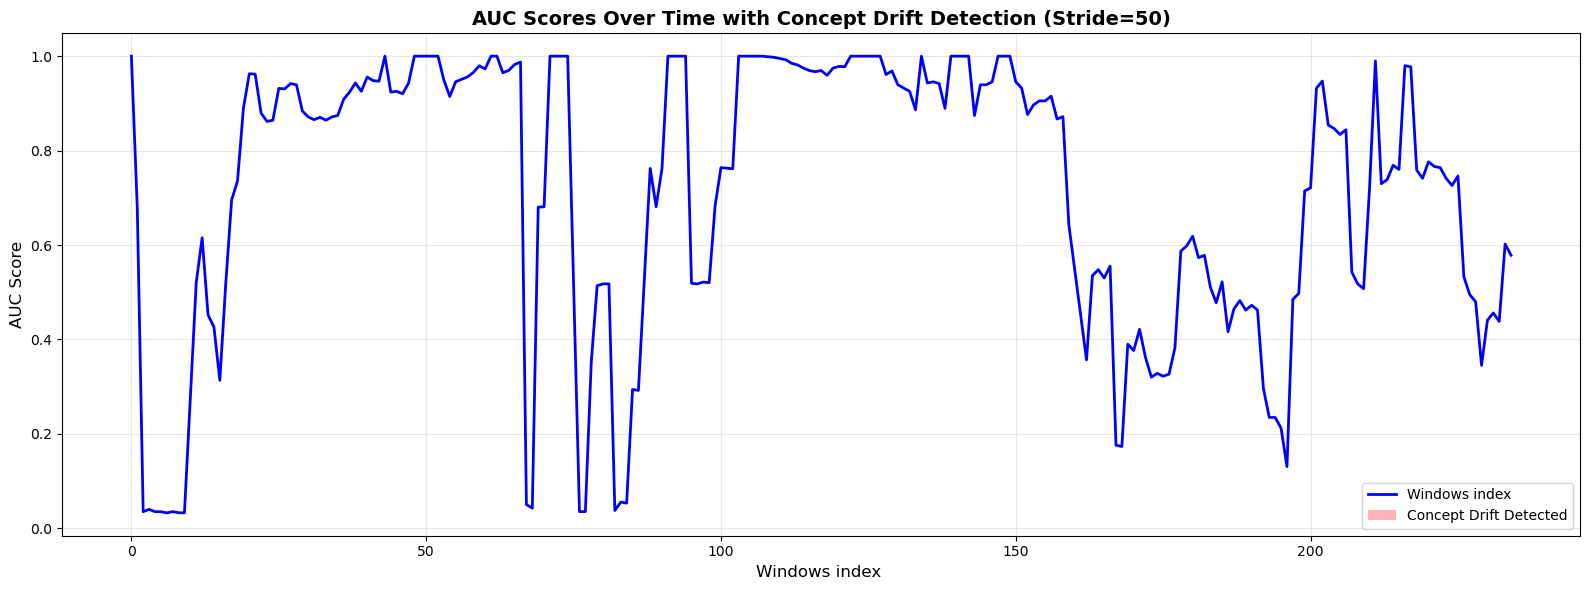

AUC Golbal results  0.6742860264428455:
Stride=100: 116 fenêtres, 0 drifts détectés


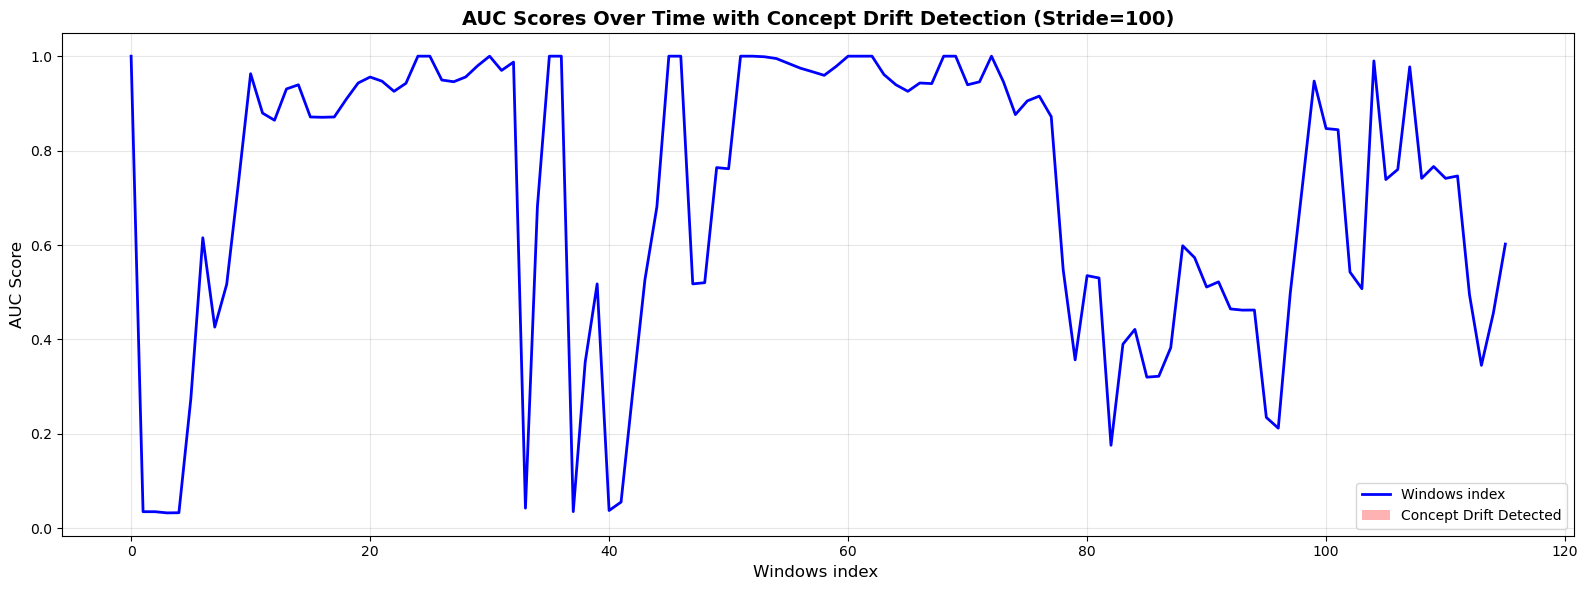

AUC Golbal results  0.6793161767695247:
Stride=200: 57 fenêtres, 0 drifts détectés


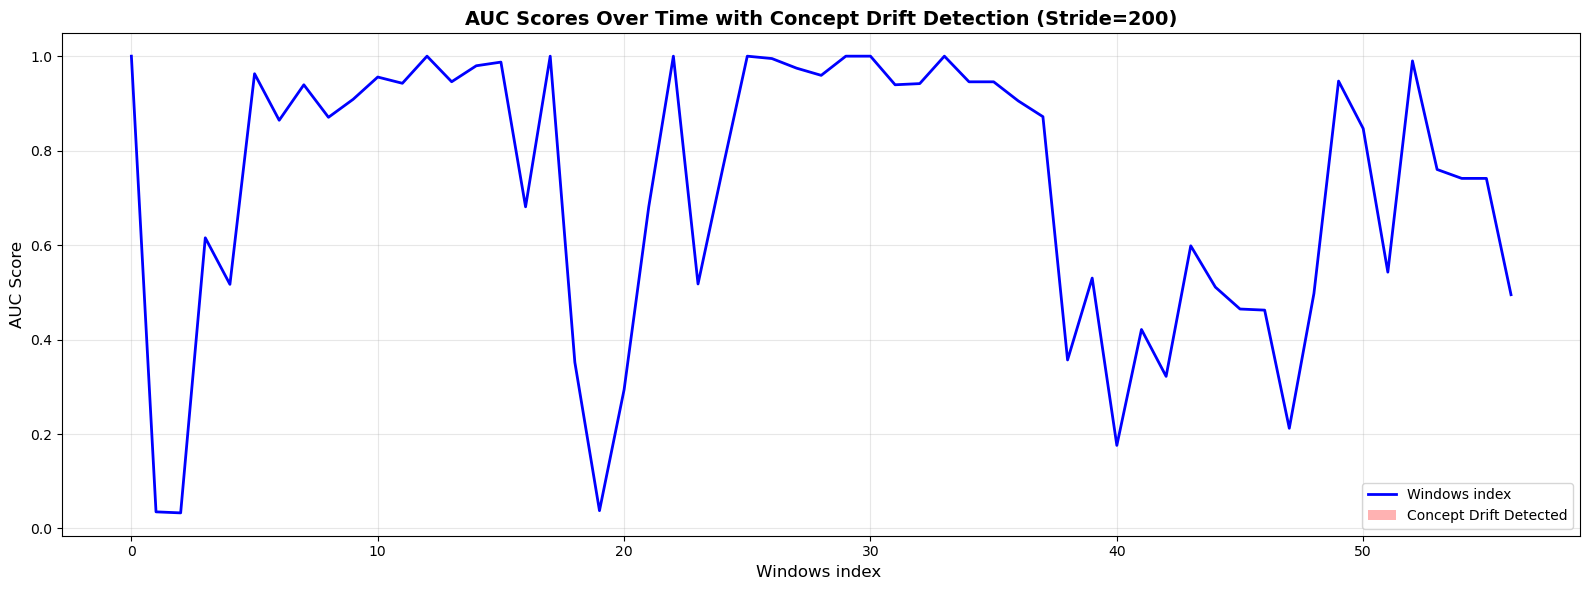

In [29]:
for i, stride_value in enumerate([1, 10, 50, 100, 200]):
    auc_lists = results[i][3]
    drift_indicators = results[i][1]
    print(f"AUC Golbal results  {results[i][2]}:")
    print(f"Stride={stride_value}: {len(auc_lists)} fenêtres, "
          f"{sum(drift_indicators)} drifts détectés")
    plot_auc_with_drift(auc_lists, drift_indicators, xlabel="Windows index ", ylabel="AUC Score", title=f"AUC Scores Over Time with Concept Drift Detection (Stride={stride_value})")